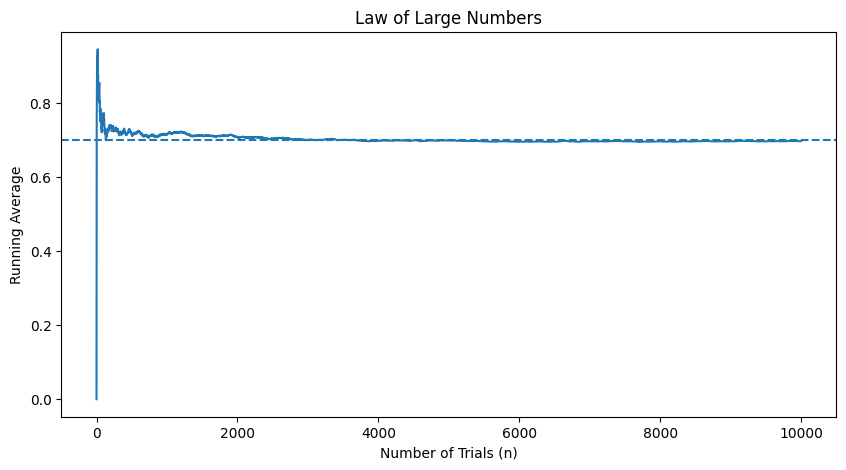

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = 10000
p = 0.7

trials = np.random.binomial(1, p, n)

cumulative_avg = np.cumsum(trials) / np.arange(1, n + 1)

plt.figure(figsize=(10,5))
plt.plot(cumulative_avg) 
plt.axhline(y=p, linestyle='--')
plt.xlabel("Number of Trials (n)")
plt.ylabel("Running Average")
plt.title("Law of Large Numbers")
plt.show()

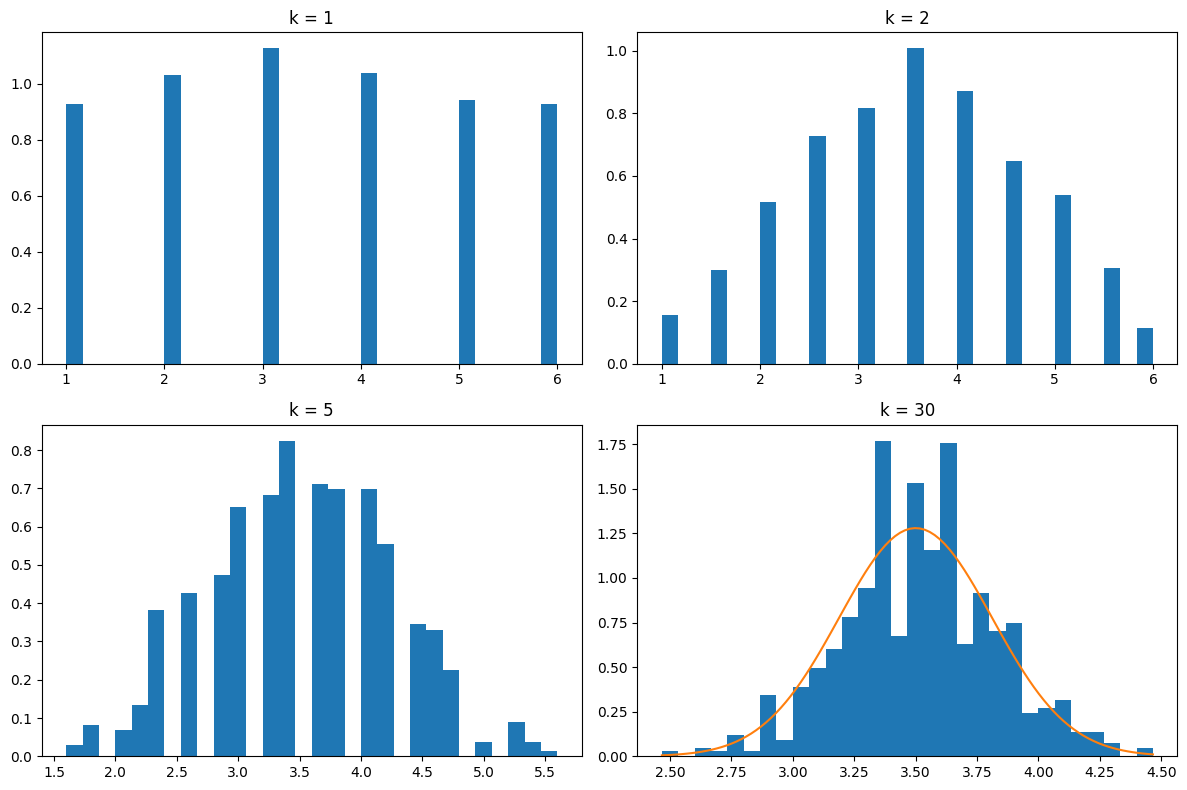

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

m = 1000
k_values = [1, 2, 5, 30]

mu = 3.5
sigma = np.sqrt(35/12)

plt.figure(figsize=(12,8))

for i, k in enumerate(k_values):
    sample_means = []

    for _ in range(m):
        dice = np.random.randint(1, 7, k)
        sample_means.append(np.mean(dice))

    sample_means = np.array(sample_means)

    plt.subplot(2, 2, i+1)
    plt.hist(sample_means, bins=30, density=True)

    # Overlay ONLY for k = 30
    if k == 30:
        x = np.linspace(min(sample_means), max(sample_means), 100)
        normal_pdf = stats.norm.pdf(x, mu, sigma/np.sqrt(k))
        plt.plot(x, normal_pdf)

    plt.title("k = " + str(k))

plt.tight_layout()
plt.show()

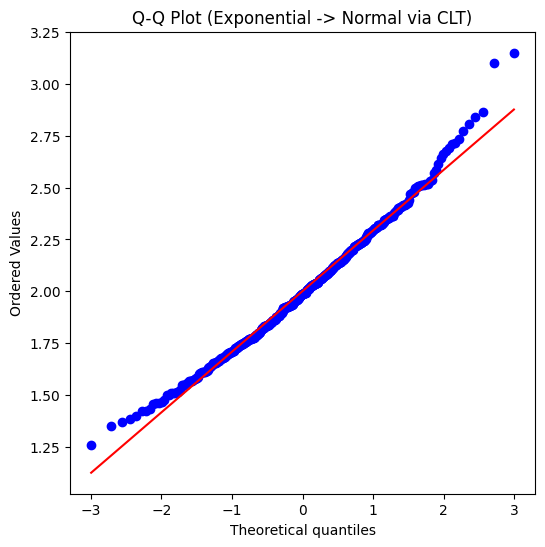

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

lam = 0.5
n = 50
m = 500

sample_means = []

for _ in range(m):
    sample = np.random.exponential(scale=1/lam, size=n)
    sample_means.append(np.mean(sample))

sample_means = np.array(sample_means)

# Q-Q Plot
plt.figure(figsize=(6,6))
stats.probplot(sample_means, dist="norm", plot=plt)
plt.title("Q-Q Plot (Exponential -> Normal via CLT)")
plt.show()

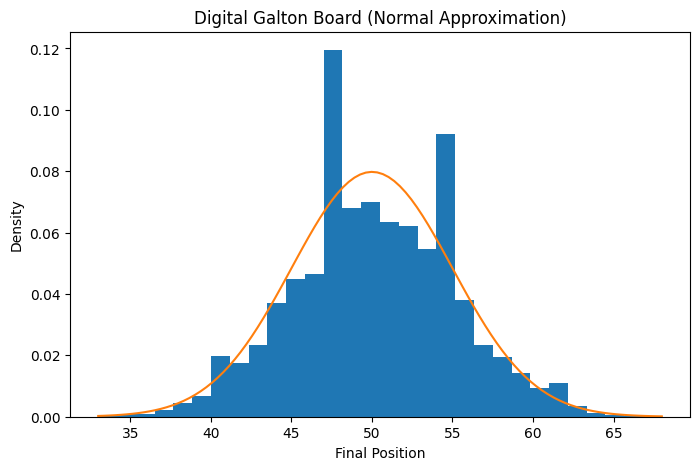

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

N = 100
balls = 5000

positions = []

for _ in range(balls):
    steps = np.random.binomial(1, 0.5, N)
    positions.append(np.sum(steps))

positions = np.array(positions)

plt.figure(figsize=(8,5))
plt.hist(positions, bins=30, density=True)

# Overlay normal approximation
mu = N * 0.5
sigma = np.sqrt(N * 0.5 * 0.5)

x = np.linspace(min(positions), max(positions), 100)
normal_curve = stats.norm.pdf(x, mu, sigma)

plt.plot(x, normal_curve)

plt.xlabel("Final Position")
plt.ylabel("Density")
plt.title("Digital Galton Board (Normal Approximation)")
plt.show()